# Important Links

### GEFS-R Yearly Parquet code

In [13]:
import pandas as pd
from pathlib import Path
from tqdm import tqdm

# ── Configure ───────────────────────────
input_dir  = Path(r"/nfs/spare11/dharkin/NWS_Lapenta_Project/correct_parquet_data/2019")        # your source folder
output_dir = Path(r"/nfs/spare11/dharkin/NWS_Lapenta_Project/yearly_data_files") # separate folder for output
output_dir.mkdir(parents=True, exist_ok=True)                              # create if missing
output_f   = output_dir / "year_2019.parquet"

# ── Load and Concatenate ────────────────
files = sorted(input_dir.glob("*.parquet"))

print(f"📁 Found {len(files)} files. Loading...")

dfs = []
for f in tqdm(files, desc="Reading files"):
    df = pd.read_parquet(f)

    float64_cols = df.select_dtypes(include="float64").columns
    df[float64_cols] = df[float64_cols].astype("float32")

    dfs.append(df)

df_full = pd.concat(dfs, ignore_index=True)

print(f"✅ Combined shape: {df_full.shape}")

# ── Save as one Parquet ─────────────────
df_full.to_parquet(output_f, engine="pyarrow", compression="snappy", index=False)

print(f"🎉 Saved full year to: {output_f}")


📁 Found 138 files. Loading...


Reading files: 100%|██████████| 138/138 [00:01<00:00, 91.07it/s]


✅ Combined shape: (4296474, 43)
🎉 Saved full year to: /nfs/spare11/dharkin/NWS_Lapenta_Project/yearly_data_files/year_2019.parquet


### Multi-Yearly Code

In [14]:
import pandas as pd
from pathlib import Path
from tqdm import tqdm

# ── Configure ────────────────────────────────────────────────
root_dir   = Path("/nfs/spare11/dharkin/NWS_Lapenta_Project/correct_parquet_data")
years      = ["2015", "2016", "2017", "2018", "2019"]          # change or expand as needed
output_dir = Path("/nfs/spare11/dharkin/NWS_Lapenta_Project/yearly_data_files")
output_dir.mkdir(parents=True, exist_ok=True)

output_f   = output_dir / "years_2015_2019.parquet"  # single 3‑year file

# ── Collect all 2‑day Parquets across the three years ───────
files = []
for yr in years:
    year_dir = root_dir / yr
    files.extend(sorted(year_dir.glob("*.parquet")))

print(f"📁 Found {len(files)} two‑day files across {years}. Loading...")

# ── Load, down‑cast, and concatenate ─────────────────────────
dfs = []
for f in tqdm(files, desc="Reading files"):
    df = pd.read_parquet(f)
    float64_cols = df.select_dtypes("float64").columns
    df[float64_cols] = df[float64_cols].astype("float32")
    dfs.append(df)

df_full = pd.concat(dfs, ignore_index=True)
print(f"✅ Combined shape: {df_full.shape}")

# ── Save to a single Parquet ─────────────────────────────────
df_full.to_parquet(output_f, engine="pyarrow", compression="snappy", index=False)
print(f"🎉 Saved 5‑year dataset → {output_f}")


📁 Found 690 two‑day files across ['2015', '2016', '2017', '2018', '2019']. Loading...


Reading files: 100%|██████████| 690/690 [00:07<00:00, 86.94it/s]


✅ Combined shape: (21513846, 43)
🎉 Saved 3‑year dataset → /nfs/spare11/dharkin/NWS_Lapenta_Project/yearly_data_files/years_2015_2019.parquet


### GEFS-R Download Code

In [4]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
GEFS‑R ensemble‑median → Parquet  (2‑day blocks only, JJA skipped)

• Downloads GEFS‑R reforecast GRIB2, computes ensemble‑median fields
• Adds NOHRSC snowfall (meters) + flags ≥1", ≥4", ≥6"
• Writes ONE Parquet per 2‑day block in <OUTPUT_DIR>/<YYYY>/
• Skips block if that Parquet already exists
• NOHRSC lookup works across year boundaries
• Sanity check:  python script.py --check
"""

# ────────── USER SETTINGS ──────────
from datetime import datetime, timedelta
NOHRSC_BASE = "/nfs/spare11/dharkin/NWS_Lapenta_Project/code_for_data/nohrsc_snowfall"          # parent dir containing 2014/, 2015/, …
OUTPUT_DIR  = "/nfs/spare11/dharkin/NWS_Lapenta_Project/correct_parquet_data"           # where 2‑day Parquets will go

start_date  = datetime(2019, 1, 1)              # first 00 UTC init
final_date  = datetime(2019, 1, 2)              # inclusive
block_days  = 2                             # must stay 2

num_cores, threads_per_day = 4, 8                 # parallelism

# ────────── IMPORTS & CONSTANTS ──────────
import os, asyncio, aiohttp, tempfile, xarray as xr, pathlib, re, warnings, sys, argparse
import pandas as pd, numpy as np
from tqdm import tqdm
from concurrent.futures import ProcessPoolExecutor
from scipy.interpolate import griddata, RegularGridInterpolator
from scipy.spatial import cKDTree
from shapely.geometry import Point
from shapely.prepared import prep
import cartopy.io.shapereader as shpreader
warnings.filterwarnings("ignore", category=RuntimeWarning)

base_url = "https://noaa-gefs-retrospective.s3.amazonaws.com/GEFSv12/reforecast"
members   = ["c00"] + [f"p{str(i).zfill(2)}" for i in range(1, 5)]

LAT_MIN, LAT_MAX = 40.0, 50.0
LON_MIN, LON_MAX = -105.0, -90.0
BOX_LATS = np.arange(LAT_MIN, LAT_MAX + 1e-4, 0.25)
BOX_LONS = np.arange(LON_MIN, LON_MAX + 1e-4, 0.25)

# ────────── helper: ensure <OUTPUT_DIR>/<YYYY>/ exists ──────────
def year_path(dt: datetime) -> pathlib.Path:
    p = pathlib.Path(OUTPUT_DIR) / f"{dt.year}"
    p.mkdir(parents=True, exist_ok=True)
    return p

# ────────── CONUS MASK ──────────
def load_conus_polygon():
    shp = shpreader.natural_earth("110m", "cultural", "admin_0_countries")
    for rec in shpreader.Reader(shp).records():
        if rec.attributes["NAME"] == "United States of America":
            return prep(rec.geometry)
    raise RuntimeError("CONUS polygon not found")

CONUS = load_conus_polygon()
point_in_conus = np.vectorize(lambda lat, lon: CONUS.contains(Point(lon, lat)))

# ────────── VARIABLE MAPS ──────────
varname_to_filename = {
    # near‑surface / surface
    "t2m":"tmp_2m","msl":"pres_msl","sh2":"spfh_2m","apcp":"apcp_sfc","pwat":"pwat_eatm",
    "ugrd_10m":"ugrd_hgt","vgrd_10m":"vgrd_hgt","sfcr":"sfcr_sfc","gust":"gust_sfc",
    "pbl_hgt":"pbl_hgt","sdwe":"weasd_sfc","tsoil":"tsoil_bgrnd",
    # upper‑air
    "u_700":"ugrd_pres_abv700mb","v_700":"vgrd_pres_abv700mb","t_700":"tmp_pres_abv700mb",
    "gh_700":"hgt_pres_abv700mb","q_700":"spfh_pres_abv700mb","w_700":"vvel_pres_abv700mb",
    "u_850":"ugrd_pres","v_850":"vgrd_pres","t_850":"tmp_pres",
    "gh_850":"hgt_pres","q_850":"spfh_pres","w_850":"vvel_pres",
    "u_500":"ugrd_pres_abv700mb","v_500":"vgrd_pres_abv700mb","t_500":"tmp_pres_abv700mb",
    "gh_500":"hgt_pres_abv700mb","q_500":"spfh_pres_abv700mb","w_500":"vvel_pres_abv700mb",
}
varname_to_internal = {
    "t2m":"t2m","msl":"msl","sh2":"sh2","apcp":"tp","pwat":"pwat",
    "ugrd_10m":"u10","vgrd_10m":"v10","sfcr":"fsr","gust":"gust","pbl_hgt":"unknown","sdwe":"sdwe","tsoil":"st",
    "u_700":"u","v_700":"v","t_700":"t","gh_700":"gh","q_700":"q","w_700":"w",
    "u_850":"u","v_850":"v","t_850":"t","gh_850":"gh","q_850":"q","w_850":"w",
    "u_500":"u","v_500":"v","t_500":"t","gh_500":"gh","q_500":"q","w_500":"w",
}
var_config = {k:(10 if "10m" in k else 500 if "_500" in k else
                 700 if "_700" in k else 850 if "_850" in k else None)
              for k in varname_to_filename}
var_is_hgt = {k: k in ("ugrd_10m","vgrd_10m") for k in varname_to_filename}
upper_vars = [v for v in varname_to_filename if "_700" in v or "_500" in v]
surface_vars = ["tsoil","sdwe","sfcr","pbl_hgt"]

# ────────── GRIB → DataFrame helper ──────────
def grib_to_df(buf, fname, fc_init, internal, plevel, is_hgt):
    tmp = tempfile.NamedTemporaryFile(suffix=".grib2", delete=False)
    try:
        tmp.write(buf); tmp.flush()
        keys = {"dataType":"cf" if "c00" in fname else "pf"}
        if is_hgt and plevel:
            keys |= {"typeOfLevel":"heightAboveGround","level":plevel}
        elif plevel:
            keys |= {"typeOfLevel":"isobaricInhPa","level":plevel}
        ds = xr.open_dataset(tmp.name, engine="cfgrib", filter_by_keys=keys)
        if internal == "hpbl" and "unknown" in ds:
            ds = ds.rename({"unknown":"hpbl"})
        if ds.longitude.min() >= 0:  # convert 0‑360 → ±180
            ds = ds.assign_coords(longitude=((ds.longitude+180)%360)-180)

        fld = ds[internal]
        if "depthBelowLandLayer" in fld.dims:
            fld = fld.isel(depthBelowLandLayer=0)

        frames = []
        for i in range(len(fld.step)):
            lead = int(fld.step[i].values/np.timedelta64(1,"h"))
            if 60 <= lead <= 240:
                vt  = fc_init + timedelta(hours=lead)
                arr = fld.isel(step=i)
                sub = arr.where((arr.latitude>=LAT_MIN)&(arr.latitude<=LAT_MAX)&
                                (arr.longitude>=LON_MIN)&(arr.longitude<=LON_MAX), drop=True)
                df  = sub.stack(points=("latitude","longitude")).to_series().reset_index()
                df.columns = ["latitude","longitude",internal]
                df["forecast_lead_hours"] = lead
                df["valid_time"]          = vt
                df["init_time"]           = fc_init
                frames.append(df)
        return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
    finally:
        tmp.close(); os.remove(tmp.name)

# ────────── Async download helpers ──────────
async def _fetch(sess, url, var, mem, ymdh):
    try:
        async with sess.get(url) as r:
            if r.status != 200:
                raise RuntimeError(f"HTTP {r.status}")
            buf = await r.read()
            return grib_to_df(buf, f"{var}_{ymdh}_{mem}.grib2",
                              datetime.strptime(ymdh,"%Y%m%d%H"),
                              varname_to_internal[var], var_config[var], var_is_hgt[var])
    except Exception as exc:
        print(f"❌ {var} {mem} {ymdh} – {exc}")
        return None

async def gather_day(var, init_dt):
    ymdh = init_dt.strftime("%Y%m%d")+"00"
    base = f"{base_url}/{init_dt.year}/{ymdh}"
    urls = {m: f"{base}/{m}/Days%3A1-10/{varname_to_filename[var]}_{ymdh}_{m}.grib2"
            for m in members}
    async with aiohttp.ClientSession(timeout=aiohttp.ClientTimeout(total=300)) as sess:
        tasks = [_fetch(sess,u,var,m,ymdh) for m,u in urls.items()]
        return [d for d in await asyncio.gather(*tasks) if d is not None]

def download_var_day(var, init_dt):
    dfs = asyncio.run(gather_day(var, init_dt))
    if not dfs:
        return var, None
    ivar = varname_to_internal[var]
    cat  = pd.concat(dfs, ignore_index=True)
    med  = (cat.groupby(["latitude","longitude","valid_time",
                         "forecast_lead_hours","init_time"])[ivar]
              .median().reset_index().rename(columns={ivar: var}))
    return var, med

def _wrap(args): return download_var_day(*args)

# ────────── Upper‑air fill helpers ──────────
def interp_upper(df):
    sub = df[["latitude","longitude","forecast_lead_hours"]+upper_vars] \
            .dropna(how="all", subset=upper_vars)
    if sub.empty:  # nothing missing
        return df
    ds   = sub.set_index(["forecast_lead_hours","latitude","longitude"]).to_xarray()
    ds_i = ds.interp(latitude=BOX_LATS, longitude=BOX_LONS, method="linear",
                     kwargs={"fill_value":np.nan})
    df_i = ds_i.to_dataframe().reset_index()
    merged = df.merge(df_i,on=["latitude","longitude","forecast_lead_hours"],
                      how="left",suffixes=("","_i"))
    for v in upper_vars:
        merged[v] = merged[v].fillna(merged[f"{v}_i"])
        merged.drop(columns=f"{v}_i", inplace=True)
    return merged

def fill_remaining_nans(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    tgt_pts = np.column_stack((df.latitude.values, df.longitude.values))
    for col in cols:
        na = df[col].isna().values
        if na.any() and (~na).any():
            tree = cKDTree(tgt_pts[~na])
            _, nn = tree.query(tgt_pts[na], k=1)
            df.loc[na,col] = df.loc[~na,col].values[nn]
    return df

# ────────── NOHRSC helpers ──────────
NOHRSC_RGX = re.compile(r"(\d{10})")   # yyyymmddHH
SNOW_VARS  = ["snowfall_cm","Data","snow","Snowfall"]

def bucket_end(hr): return 36 if hr<=36 else 36+24*int(np.ceil((hr-36)/24))

def find_nohrsc(dt):
    y_dir = pathlib.Path(NOHRSC_BASE) / f"{dt.year}"
    if not y_dir.is_dir(): return None
    m_dir = y_dir / dt.strftime("%Y%m")
    if not m_dir.is_dir(): return None
    for p in m_dir.iterdir():
        m = NOHRSC_RGX.search(p.name)
        if m and datetime.strptime(m.group(1),"%Y%m%d%H") == dt:
            return p
    return None

def add_nohrsc(df: pd.DataFrame, init: datetime) -> pd.DataFrame:
    df["bucket_end"] = df["forecast_lead_hours"].apply(bucket_end)
    tgt_lat = df.latitude.values
    tgt_lon = np.where(df.longitude.values<0, df.longitude.values+360, df.longitude.values)
    tgt_pts = np.column_stack((tgt_lat, tgt_lon))
    snow_out = np.full(len(df), np.nan, float)

    for end_hr in df.bucket_end.unique():
        f = find_nohrsc(init + timedelta(hours=int(end_hr)))
        if f is None: continue
        sel = df.bucket_end.values == end_hr
        ds  = xr.open_dataset(f, engine="h5netcdf")
        snow_var = next((nm for nm in SNOW_VARS if nm in ds), None)
        if snow_var is None:
            ds.close(); continue
        snow = ds[snow_var].values  # meters
        lat  = ds["lat"].values
        lon  = ds["lon"].values
        ds.close()

        if lat[0] > lat[-1]:
            lat, snow = lat[::-1], snow[::-1,:]
        if np.any(lon<0):
            lon = np.where(lon<0, lon+360, lon)
            idx = np.argsort(lon)
            lon, snow = lon[idx], snow[:,idx]

        vals = RegularGridInterpolator((lat,lon), snow,
                                       bounds_error=False, fill_value=np.nan)(tgt_pts[sel])

        miss = np.isnan(vals)
        if miss.any():
            lat2d, lon2d = np.meshgrid(lat,lon,indexing="ij")
            good = ~np.isnan(snow)
            if good.any():
                pts_src = np.column_stack((lat2d[good], lon2d[good]))
                vals_src = snow[good]
                vals[miss] = griddata(pts_src, vals_src, tgt_pts[sel][miss], method="nearest")
        snow_out[sel] = vals

    # final nearest fill
    miss = np.isnan(snow_out)
    if miss.any() and (~miss).any():
        tree = cKDTree(tgt_pts[~miss]); _, nn = tree.query(tgt_pts[miss], k=1)
        snow_out[miss] = snow_out[~miss][nn]

    df["snowfall_nohrsc_m"] = snow_out
    df["snowfall_ge_1in"] = (snow_out >= 0.0254).astype("uint8")
    df["snowfall_ge_4in"] = (snow_out >= 0.1016).astype("uint8")
    df["snowfall_ge_6in"] = (snow_out >= 0.1524).astype("uint8")
    return df.drop(columns="bucket_end")

# ────────── ML‑ready post‑processing ──────────
def prepare_training_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    water = df[surface_vars].isna().all(axis=1)
    df = df.loc[~water].reset_index(drop=True)
    for v in surface_vars:
        df[f"{v}_missing"] = df[v].isna().astype("uint8")
    df[surface_vars] = df[surface_vars].fillna(df[surface_vars].median())
    return df

# ────────── PROCESS ONE INIT DAY (NO file I/O) ──────────
def process_day(init_dt):
    with ProcessPoolExecutor(max_workers=threads_per_day) as ex:
        res = list(ex.map(_wrap, [(v,init_dt) for v in varname_to_filename]))
    data = {v:d for v,d in res if d is not None}
    if not data:
        return None

    df = None
    for dv in data.values():
        df = dv if df is None else df.merge(
            dv,
            on=["latitude","longitude","valid_time",
                "forecast_lead_hours","init_time"],
            how="outer"
        )

    df = df[(df.latitude>=LAT_MIN)&(df.latitude<=LAT_MAX)&
            (df.longitude>=LON_MIN)&(df.longitude<=LON_MAX)]
    df = df[point_in_conus(df.latitude.values, df.longitude.values)]

    df = interp_upper(df)
    df = fill_remaining_nans(df, upper_vars)

    df = df[((np.round((df.latitude - LAT_MIN)*100)%75)==0) &
            ((np.round((df.longitude- LON_MIN)*100)%75)==0)]

    df = add_nohrsc(df, init_dt)
    df = prepare_training_dataframe(df)
    return df

# ────────── MAIN loop (skip duplicates & JJA) ──────────
def main():
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    cur_start = start_date
    while cur_start <= final_date:
        # skip summer months
        if {(cur_start+timedelta(i)).month for i in range(block_days)} & {6,7,8}:
            print(f"⏭ Skipping {cur_start:%Y%m%d}-{(cur_start+timedelta(block_days-1)):%Y%m%d} (JJA)")
            cur_start += timedelta(days=block_days); continue

        # combined parquet path
        out_parquet = (year_path(cur_start) /
                       f"ensemble_median_allvars_{cur_start:%Y%m%d}_{(cur_start+timedelta(1)):%Y%m%d}.parquet")
        if out_parquet.exists():
            print(f"✔ Block already done → {out_parquet.relative_to(OUTPUT_DIR)}")
            cur_start += timedelta(days=block_days); continue

        # process the two init days
        days = [cur_start + timedelta(i) for i in range(block_days)]
        with ProcessPoolExecutor(max_workers=num_cores) as ex:
            dfs = list(tqdm(ex.map(process_day, days),
                            total=len(days), desc=f"{cur_start:%Y%m%d} block"))
        dfs = [df for df in dfs if df is not None]
        if not dfs:
            print(f"⚠️ No data for block starting {cur_start:%Y%m%d}")
            cur_start += timedelta(days=block_days); continue

        pd.concat(dfs, ignore_index=True).to_parquet(out_parquet, index=False)
        print(f"🎉 Saved 2‑day Parquet → {out_parquet.relative_to(OUTPUT_DIR)}")

        cur_start += timedelta(days=block_days)

# ────────── SANITY CHECK (optional) ──────────
def sanity_check():
    for dt in (datetime(2014,12,31,12), datetime(2015,1,1,12)):
        print(f"{dt:%Y-%m-%d %HZ} → {find_nohrsc(dt)}")

# ────────── CLI ENTRY ──────────
if __name__ == "__main__":
    ap = argparse.ArgumentParser()
    ap.add_argument("--check", action="store_true",
                    help="Run NOHRSC path sanity test and exit")
    args = ap.parse_known_args()[0]

    if args.check:
        sanity_check()
        sys.exit(0)

    main()


20190101 block: 100%|██████████| 2/2 [05:18<00:00, 159.17s/it]

🎉 Saved 2‑day Parquet → 2019/ensemble_median_allvars_20190101_20190102.parquet


### GEFS-R File QC

In [11]:
import pandas as pd

def nan_zero_counts_from_parquet(parquet_path):
    # Load DataFrame from parquet
    df = pd.read_parquet('/nfs/spare11/dharkin/NWS_Lapenta_Project/yearly_data_files/years_2015_2019.parquet')
    
    summary = {}
    for col in df.columns:
        col_data = df[col]
        n_nans = col_data.isna().sum()
        # For zeros, only count for numeric columns, skip others
        if pd.api.types.is_numeric_dtype(col_data):
            n_zeros = (col_data == 0).sum()
        else:
            n_zeros = 'N/A'  # Not applicable for non-numeric
        if n_zeros != 'N/A':
            n_nonzeros = col_data.size - n_nans - n_zeros
        else:
            n_nonzeros = col_data.size - n_nans
        summary[col] = {
            'NaNs': n_nans,
            'Zeros': n_zeros,
            'Non-zeros': n_nonzeros
        }
    
    summary_df = pd.DataFrame(summary).T
    print(f"Stats for parquet file: {parquet_path}\n")
    print(summary_df)

# Example usage:
nan_zero_counts_from_parquet("/nfs/spare11/dharkin/NWS_Lapenta_Project/yearly_data_files/year_2015_2019.parquet")


Stats for parquet file: /nfs/spare11/dharkin/NWS_Lapenta_Project/yearly_data_files/year_2015_2019.parquet

                      NaNs     Zeros Non-zeros
latitude                 0         0  21372204
longitude                0         0  21372204
valid_time               0       N/A  21372204
forecast_lead_hours      0         0  21372204
init_time                0       N/A  21372204
t2m                      0         0  21372204
msl                      0         0  21372204
sh2                      0         0  21372204
apcp                     0  16879647   4492557
pwat                     0         0  21372204
ugrd_10m                 0         8  21372196
vgrd_10m                 0         6  21372198
sfcr                     0    141894  21230310
gust                     0         0  21372204
pbl_hgt                  0         0  21372204
sdwe                     0  12806886   8565318
tsoil                    0         0  21372204
u_700                    0         0  21372204


In [15]:
#!/usr/bin/env python3
"""
nan_zero_report_with_init.py
-----------------------------
• Load a Parquet file
• Count NaNs, zeros, and non-zeros per column
• Print the first N NaN locations with:
   → row index, valid_time, forecast_lead_hours, init_time, column
• Optionally save the full NaN list to CSV
"""

from pathlib import Path
import pandas as pd

def nan_zero_report(
    parquet_path: str | Path,
    datetime_col: str = "valid_time",
    fhour_col: str = "forecast_lead_hours",
    init_col: str = "init_time",
    show_first: int = 20,
    save_coords_csv: str | None = None,
):
    parquet_path = Path(parquet_path)
    df = pd.read_parquet(parquet_path)

    # Ensure required columns exist
    for required in (datetime_col, fhour_col, init_col):
        if required not in df.columns:
            raise ValueError(f"Column '{required}' not found in DataFrame.")

    # ── 1. Summary table of NaNs/Zeros ─────────────────────
    summary = {}
    for col in df.columns:
        col_data = df[col]
        n_nans = col_data.isna().sum()
        n_zeros = (col_data == 0).sum() if pd.api.types.is_numeric_dtype(col_data) else "N/A"
        n_nonzeros = col_data.size - n_nans - (n_zeros if isinstance(n_zeros, int) else 0)
        summary[col] = {"NaNs": n_nans, "Zeros": n_zeros, "Non-zeros": n_nonzeros}

    print(f"\n📊  Column summary for: {parquet_path}\n")
    print(pd.DataFrame(summary).T)

    # ── 2. Find coordinates of NaNs ────────────────────────
    nan_mask = df.isna()
    rows, cols = nan_mask.to_numpy().nonzero()

    coord_data = []
    for r, c in zip(rows, cols):
        row_idx   = df.index[r]
        valid_t   = df.iat[r, df.columns.get_loc(datetime_col)]
        fhour     = df.iat[r, df.columns.get_loc(fhour_col)]
        init_t    = df.iat[r, df.columns.get_loc(init_col)]
        column_nm = df.columns[c]
        coord_data.append((row_idx, valid_t, fhour, init_t, column_nm))

    # ── 3. Preview and export ──────────────────────────────
    if coord_data:
        preview = coord_data[:show_first]
        print(f"\n🕵️  First {len(preview)} NaN locations:")
        for row_idx, vt, fh, init_t, col in preview:
            print(f"   row={row_idx}, time={vt}, fhr={fh}, init={init_t}, column={col}")
    else:
        print("\n✅ No NaNs found in this dataset.")

    if save_coords_csv and coord_data:
        pd.DataFrame(
            coord_data,
            columns=["row_index", datetime_col, fhour_col, init_col, "column_with_nan"]
        ).to_csv(save_coords_csv, index=False)
        print(f"\n💾  Full NaN list saved → {save_coords_csv}")

    print(f"\n🧮  Total NaN cells: {len(coord_data):,}")

# ───────────────────────────────────────────────────────────────
if __name__ == "__main__":
    nan_zero_report(
        "/nfs/spare11/dharkin/NWS_Lapenta_Project/yearly_data_files/years_2015_2019.parquet",
        datetime_col="valid_time",
        fhour_col="forecast_lead_hours",
        init_col="init_time",
        show_first=30,
        save_coords_csv="nan_with_dates_fhour_init.csv"
    )



📊  Column summary for: /nfs/spare11/dharkin/NWS_Lapenta_Project/yearly_data_files/years_2015_2019.parquet

                      NaNs     Zeros Non-zeros
latitude                 0         0  21372204
longitude                0         0  21372204
valid_time               0       N/A  21372204
forecast_lead_hours      0         0  21372204
init_time                0       N/A  21372204
t2m                      0         0  21372204
msl                      0         0  21372204
sh2                      0         0  21372204
apcp                     0  16879647  21372204
pwat                     0         0  21372204
ugrd_10m                 0         8  21372204
vgrd_10m                 0         6  21372204
sfcr                     0    141894  21372204
gust                     0         0  21372204
pbl_hgt                  0         0  21372204
sdwe                     0  12806886  21372204
tsoil                    0         0  21372204
u_700                    0         0  21372204

### NOHRSC Download

In [2]:
#!/usr/bin/env python3
"""
Download NOHRSC 24‑h CONUS snowfall analyses (.nc) for a given date range
and store them in a year/month folder hierarchy under the user‑specified
root directory, **skipping July and August**.

Author : You 😊
Date   : 2025‑07‑01
"""

import requests
from datetime import datetime, timedelta
from pathlib import Path

# ───────────── USER SETTINGS ──────────────────────────────────────────────
year = 2020                              # ← change the year as needed

# Choose any contiguous date range inside that year
start_date = datetime(year, 1, 1)
end_date   = datetime(year, 1, 12)      # inclusive

# Root directory where *all* snowfall files will live
output_root = Path("/nfs/spare11/dharkin/NWS_Lapenta_Project/code_for_data/nohrsc_snowfall")
# ──────────────────────────────────────────────────────────────────────────


# ---------- Prep date list ----------
dates = [start_date + timedelta(days=i)
         for i in range((end_date - start_date).days + 1)]

total_bytes_downloaded = 0
total_files_downloaded = 0

year_dir = output_root / str(year)
year_dir.mkdir(parents=True, exist_ok=True)

# ---------- Main loop ----------
for date in dates:

    # ── Skip summer months (July & August) ───────────────────────────
    if date.month in (7, 8):
        continue
    # ----------------------------------------------------------------

    try:
        yyyymm   = date.strftime("%Y%m")
        yyyymmdd = date.strftime("%Y%m%d")
        filename = f"sfav2_CONUS_24h_{yyyymmdd}12.nc"
        url      = f"https://www.nohrsc.noaa.gov/snowfall/data/{yyyymm}/{filename}"

        month_dir = year_dir / yyyymm       # e.g. …/nohrsc_snowfall/2015/201501/
        month_dir.mkdir(exist_ok=True)

        local_path = month_dir / filename

        if local_path.exists():
            print(f"✔ Already exists: {local_path}")
            continue

        print(f"⬇ Downloading {url}")
        response = requests.get(url, timeout=60)
        response.raise_for_status()

        local_path.write_bytes(response.content)
        file_size = local_path.stat().st_size
        total_bytes_downloaded += file_size
        total_files_downloaded += 1

        print(f"✓ Saved → {local_path}  ({file_size / 1e6:.2f} MB)")

    except Exception as e:
        print(f"✗ Failed {date.strftime('%Y-%m-%d')}: {e}")

# ---------- Summary ----------
print("\n───────── SUMMARY ─────────")
print(f"Finished downloading {total_files_downloaded} files for {year} (excluding July & August).")
print(f"Total download size: {total_bytes_downloaded / 1e6:.2f} MB "
      f"({total_bytes_downloaded / 1e9:.3f} GB)")
print("Output root:", output_root.resolve())


⬇ Downloading https://www.nohrsc.noaa.gov/snowfall/data/202001/sfav2_CONUS_24h_2020010112.nc
✓ Saved → /nfs/spare11/dharkin/NWS_Lapenta_Project/code_for_data/nohrsc_snowfall/2020/202001/sfav2_CONUS_24h_2020010112.nc  (0.63 MB)
⬇ Downloading https://www.nohrsc.noaa.gov/snowfall/data/202001/sfav2_CONUS_24h_2020010212.nc
✓ Saved → /nfs/spare11/dharkin/NWS_Lapenta_Project/code_for_data/nohrsc_snowfall/2020/202001/sfav2_CONUS_24h_2020010212.nc  (0.70 MB)
⬇ Downloading https://www.nohrsc.noaa.gov/snowfall/data/202001/sfav2_CONUS_24h_2020010312.nc
✓ Saved → /nfs/spare11/dharkin/NWS_Lapenta_Project/code_for_data/nohrsc_snowfall/2020/202001/sfav2_CONUS_24h_2020010312.nc  (0.57 MB)
⬇ Downloading https://www.nohrsc.noaa.gov/snowfall/data/202001/sfav2_CONUS_24h_2020010412.nc
✓ Saved → /nfs/spare11/dharkin/NWS_Lapenta_Project/code_for_data/nohrsc_snowfall/2020/202001/sfav2_CONUS_24h_2020010412.nc  (0.45 MB)
⬇ Downloading https://www.nohrsc.noaa.gov/snowfall/data/202001/sfav2_CONUS_24h_2020010512.nc

In [28]:
import pandas as pd
from pathlib import Path

# File paths
input_parquet = Path("/nfs/spare11/dharkin/NWS_Lapenta_Project/yearly_data_files/years_2015_2019.parquet")
output_parquet = Path("/nfs/spare11/dharkin/NWS_Lapenta_Project/yearly_data_files/years_2015_2019_with_lapse.parquet")

# Load data
df = pd.read_parquet(input_parquet)

# Calculate lapse rates (°C/km)
# Formula: lapse_rate = (T_lower - T_upper) / ((Z_upper - Z_lower) / 1000)
# Note: Temperatures in K, height in meters; difference in K or °C same for lapse rate
df['lapse_500_700'] = (df['t_500'] - df['t_700']) / ((df['gh_700'] - df['gh_500']) / 1000)
df['lapse_700_850'] = (df['t_700'] - df['t_850']) / ((df['gh_850'] - df['gh_700']) / 1000)

# Replace infinite values caused by zero height differences with NaN
df['lapse_500_700'].replace([float('inf'), -float('inf')], pd.NA, inplace=True)
df['lapse_700_850'].replace([float('inf'), -float('inf')], pd.NA, inplace=True)

# Optional: remove any extreme or physically impossible lapse rates (e.g., negative or extremely large)
df.loc[df['lapse_500_700'] < 0, 'lapse_500_700'] = pd.NA
df.loc[df['lapse_700_850'] < 0, 'lapse_700_850'] = pd.NA
df.loc[df['lapse_500_700'] > 20, 'lapse_500_700'] = pd.NA  # cutoff ~20 °C/km (very extreme)
df.loc[df['lapse_700_850'] > 20, 'lapse_700_850'] = pd.NA

# Save new parquet with lapse rates added
df.to_parquet(output_parquet, engine='pyarrow', compression='snappy', index=False)

print(f"Lapse rates successfully added and saved to: {output_parquet}")


/tmp/ipykernel_218867/1809991450.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['lapse_500_700'].replace([float('inf'), -float('inf')], pd.NA, inplace=True)
/tmp/ipykernel_218867/1809991450.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[co

Lapse rates successfully added and saved to: /nfs/spare11/dharkin/NWS_Lapenta_Project/yearly_data_files/years_2015_2019_with_lapse.parquet


In [29]:
import pandas as pd

parquet_path = "/nfs/spare11/dharkin/NWS_Lapenta_Project/yearly_data_files/years_2015_2019_with_lapse.parquet"

# Load the parquet file into a DataFrame
df = pd.read_parquet(parquet_path)

# Print the column names
print("Columns in the Parquet file:")
print(df.columns.tolist())

# Optionally, preview first few rows
print(df.head())


Columns in the Parquet file:
['latitude', 'longitude', 'valid_time', 'forecast_lead_hours', 'init_time', 't2m', 'msl', 'sh2', 'apcp', 'pwat', 'ugrd_10m', 'vgrd_10m', 'sfcr', 'gust', 'pbl_hgt', 'sdwe', 'tsoil', 'u_700', 'v_700', 't_700', 'gh_700', 'q_700', 'w_700', 'u_850', 'v_850', 't_850', 'gh_850', 'q_850', 'w_850', 'u_500', 'v_500', 't_500', 'gh_500', 'q_500', 'w_500', 'snowfall_nohrsc_m', 'snowfall_ge_1in', 'snowfall_ge_4in', 'snowfall_ge_6in', 'tsoil_missing', 'sdwe_missing', 'sfcr_missing', 'pbl_hgt_missing', 'lapse_500_700', 'lapse_700_850']
   latitude  longitude          valid_time  forecast_lead_hours  init_time  \
0      40.0     -105.0 2015-01-03 12:00:00                   60 2015-01-01   
1      40.0     -105.0 2015-01-03 15:00:00                   63 2015-01-01   
2      40.0     -105.0 2015-01-03 18:00:00                   66 2015-01-01   
3      40.0     -105.0 2015-01-03 21:00:00                   69 2015-01-01   
4      40.0     -105.0 2015-01-04 00:00:00             

In [3]:
import numpy as np
import pandas as pd

# --- Constants ---
EPS = 0.622  # Rd / Rv

def rh_from_q(T_K, p_Pa, q):
    T_C = T_K - 273.15
    es = 6.112 * np.exp((17.67 * T_C) / (T_C + 243.5))        # hPa
    e = (q * p_Pa) / (EPS + (1 - EPS) * q) / 100.0           # Pa → hPa
    RH = 100.0 * e / es
    return np.clip(RH, 0.0, 100.0).astype(np.float32)

def wetbulb_stull(T_C, RH):
    Tw = (T_C * np.arctan(0.151977 * np.sqrt(RH + 8.313659))
          + np.arctan(T_C + RH)
          - np.arctan(RH - 1.676331)
          + 0.00391838 * RH**1.5 * np.arctan(0.023101 * RH)
          - 4.686035)
    return Tw.astype(np.float32)

def calculate_phase_metrics(df):
    # Surface wet-bulb
    RH_sfc = rh_from_q(df["t2m"].values, df["msl"].values, df["sh2"].values)
    df["wetbulb_sfc"] = wetbulb_stull(df["t2m"].values - 273.15, RH_sfc)

    # 850 mb wet-bulb
    p850 = 85000.0  # Pa
    RH_850 = rh_from_q(df["t_850"].values, p850, df["q_850"].values)
    df["wetbulb_850"] = wetbulb_stull(df["t_850"].values - 273.15, RH_850)

    # Freezing-level height interpolation
    T_sfc = df["t2m"].values - 273.15
    T_850 = df["t_850"].values - 273.15
    T_700 = df["t_700"].values - 273.15
    z_850 = df["gh_850"].values
    z_700 = df["gh_700"].values

    fl = np.full_like(T_sfc, np.nan, dtype=np.float32)

    # Case 1: freezing level between surface and 850 mb
    mask1 = np.sign(T_sfc) * np.sign(T_850) <= 0
    frac1 = np.divide(0 - T_sfc, T_850 - T_sfc, where=mask1 & (T_850 != T_sfc))
    fl[mask1] = (frac1[mask1] * z_850[mask1]).astype(np.float32)

    # Case 2: freezing level between 850 and 700 mb
    mask2 = ~mask1 & (np.sign(T_850) * np.sign(T_700) <= 0)
    frac2 = np.divide(0 - T_850, T_700 - T_850, where=mask2 & (T_700 != T_850))
    fl[mask2] = (z_850[mask2] + frac2[mask2] * (z_700[mask2] - z_850[mask2])).astype(np.float32)

    df["freezing_level_m"] = fl

    return df

# ————————————————————————————————————

input_parquet = "/nfs/spare11/dharkin/NWS_Lapenta_Project/yearly_data_files/years_2015_2019_with_lapse.parquet"
output_parquet = "/nfs/spare11/dharkin/NWS_Lapenta_Project/yearly_data_files/years_2015_2019_with_phase.parquet"

print("Loading Parquet data...")
df = pd.read_parquet(input_parquet)

print("Calculating phase metrics...")
df = calculate_phase_metrics(df)

print("Saving augmented data to Parquet...")
df.to_parquet(output_parquet, engine="pyarrow", compression="zstd")

print(f"Done! Saved to {output_parquet}")


Loading Parquet data...
Calculating phase metrics...
Saving augmented data to Parquet...
Done! Saved to /nfs/spare11/dharkin/NWS_Lapenta_Project/yearly_data_files/years_2015_2019_with_phase.parquet


In [7]:
import pandas as pd

input_parquet = "/nfs/spare11/dharkin/NWS_Lapenta_Project/yearly_data_files/years_2015_2019_trimmed.parquet"

# Load the Parquet file
df = pd.read_parquet(input_parquet)

# Columns to QC/display
columns_to_show = [
    "latitude", "longitude", "valid_time",
    "t2m", "sh2", "msl",
    "t_850", "q_850", "gh_850",
    "t_700", "gh_700",
    "wetbulb_sfc", "wetbulb_850", "freezing_level_m"
]

# Filter columns that exist in df (in case some are missing)
cols_existing = [col for col in columns_to_show if col in df.columns]

# Display first 20 rows for QC
display(df[cols_existing].head(20))


,latitude,longitude,valid_time,t2m,sh2,msl,t_850,q_850,gh_850,t_700,gh_700,wetbulb_sfc,wetbulb_850
0,40.0,-105.0,2015-01-03 12:00:00,267.210510,0.001920,101069.773438,271.019257,0.002107,1399.017090,269.134094,2944.664307,-7.413101,-5.116041
1,40.0,-105.0,2015-01-03 15:00:00,268.855560,0.002620,101384.132812,270.881989,0.002621,1421.518066,264.997681,2950.978516,-4.760162,-4.517145
2,40.0,-105.0,2015-01-03 18:00:00,270.668365,0.003270,101512.375000,271.600037,0.003358,1438.986816,263.500000,2960.128174,-2.630930,-2.892946
3,40.0,-105.0,2015-01-03 21:00:00,265.913757,0.002510,101980.609375,266.603058,0.002549,1447.747925,263.249359,2950.725342,-7.419390,-7.209537
4,40.0,-105.0,2015-01-04 00:00:00,262.187256,0.001810,102694.992188,263.321014,0.001942,1484.676392,258.955719,2968.533203,-11.172462,-10.546085
5,40.0,-105.0,2015-01-04 03:00:00,259.964172,0.001450,103288.796875,260.952576,0.001556,1516.850464,259.299988,2987.910889,-13.411415,-13.030411
6,40.0,-105.0,2015-01-04 06:00:00,256.390076,0.001020,103651.031250,257.542877,0.001135,1520.698608,260.399994,2994.982422,-17.011059,-16.492195
7,40.0,-105.0,2015-01-04 09:00:00,254.875534,0.000850,103717.210938,256.860413,0.000955,1519.104004,260.700012,3001.812256,-18.656796,-17.420944
8,40.0,-105.0,2015-01-04 12:00:00,255.593079,0.000860,103453.109375,258.903717,0.001026,1509.560669,261.786224,3003.932861,-18.138296,-15.651072
9,40.0,-105.0,2015-01-04 15:00:00,258.223816,0.001006,103227.914062,261.566162,0.001115,1515.429321,262.769165,3013.790771,-15.772048,-13.371334


In [6]:
import pandas as pd

# 1) Load the Parquet file
input_path  = "/nfs/spare11/dharkin/NWS_Lapenta_Project/yearly_data_files/years_2015_2019_with_phase.parquet"
df = pd.read_parquet(input_path)

# 2) Drop the column(s) you don’t need
#    Replace "column_to_drop" with your actual column name(s)
cols_to_drop = ["freezing_level_m"]          # for multiple columns: ["col1", "col2", ...]
df = df.drop(columns=cols_to_drop)

# 3) (Optional) Save the updated DataFrame
output_path = "/nfs/spare11/dharkin/NWS_Lapenta_Project/yearly_data_files/years_2015_2019_trimmed.parquet"
df.to_parquet(output_path, engine="pyarrow", compression="zstd")

print("Done! Columns dropped and file saved.")


Done! Columns dropped and file saved.


In [31]:
import pandas as pd
from pathlib import Path

# Load the parquet file
pq_file = Path("/nfs/spare11/dharkin/NWS_Lapenta_Project/yearly_data_files/years_2015_2019_with_lapse.parquet")
df = pd.read_parquet(pq_file)

# List your lapse rate columns here
lapse_rate_cols = ['lapse_500_700', 'lapse_700_850']  # Adjust if you named them differently

for col in lapse_rate_cols:
    if col in df.columns:
        n_pos = (df[col] > 0).sum()
        n_neg = (df[col] < 0).sum()
        n_zero = (df[col] == 0).sum()
        total = len(df)
        print(f"{col}:")
        print(f"  Positive lapse rates: {n_pos} ({n_pos/total:.2%})")
        print(f"  Negative lapse rates: {n_neg} ({n_neg/total:.2%})")
        print(f"  Zero lapse rates:     {n_zero} ({n_zero/total:.2%})")
        print()
    else:
        print(f"Column {col} not found in the dataframe.")


lapse_500_700:
  Positive lapse rates: 21371672 (100.00%)
  Negative lapse rates: 0 (0.00%)
  Zero lapse rates:     3 (0.00%)

lapse_700_850:
  Positive lapse rates: 20396526 (95.43%)
  Negative lapse rates: 0 (0.00%)
  Zero lapse rates:     902 (0.00%)



### FIxing Grid Points

### Interpolation test

In [9]:
import pandas as pd
import numpy as np
from scipy.interpolate import griddata

# --- USER INPUTS ---

# Target points where data is missing (latitude, longitude)
target_points = np.array([
    (49.0, -103.5),
    (49.0, -102.75),
    (49.0, -102.0),
    (49.0, -101.25),
])

# Path to your existing parquet file with full GEFS-R data
parquet_path = "/nfs/spare11/dharkin/NWS_Lapenta_Project/correct_parquet_data/2017/ensemble_median_allvars_20170220_20170221.parquet"

# GEFS-R variables you want to interpolate
vars_to_interp = [
    "t2m", "msl", "sh2", "apcp", "ugrd_10m", "vgrd_10m", "sfcr", "gust",
    "pbl_hgt", "sdwe", "tsoil",
    "u_700", "v_700", "t_700", "gh_700", "q_700", "w_700",
    "u_850", "v_850", "t_850", "gh_850", "q_850", "w_850",
    "u_500", "v_500", "t_500", "gh_500", "q_500", "w_500",
]

# --- LOAD DATA ---

df = pd.read_parquet(parquet_path)

# --- INTERPOLATE PER LEAD TIME ---

interpolated_frames = []

# Group by lead time (and optionally init_time if you want)
for (lead, init), group in df.groupby(["forecast_lead_hours", "init_time"]):

    grid_points = np.column_stack((group["latitude"].values, group["longitude"].values))

    row = {
        "forecast_lead_hours": lead,
        "init_time": init,
        "latitude": target_points[:, 0],
        "longitude": target_points[:, 1],
    }

    # Interpolate each variable
    for var in vars_to_interp:
        if var not in group.columns:
            continue
        values = group[var].values
        vals = griddata(grid_points, values, target_points, method="linear")

        # Fallback to nearest if NaNs
        nan_mask = np.isnan(vals)
        if nan_mask.any():
            vals[nan_mask] = griddata(grid_points, values, target_points[nan_mask], method="nearest")

        row[var] = vals

    interpolated_df = pd.DataFrame(row)
    interpolated_frames.append(interpolated_df)

# Combine all lead times
final_df = pd.concat(interpolated_frames, ignore_index=True)

# --- OPTIONAL: Save to Parquet or CSV ---
# final_df.to_parquet("interpolated_patch_20170220_20170221.parquet", index=False)

print(final_df.head())


   forecast_lead_hours  init_time  latitude  longitude         t2m  \
0                   60 2017-02-20      49.0    -103.50  273.338745   
1                   60 2017-02-20      49.0    -102.75  272.678436   
2                   60 2017-02-20      49.0    -102.00  271.768433   
3                   60 2017-02-20      49.0    -101.25  271.768433   
4                   60 2017-02-21      49.0    -103.50  269.779999   

             msl       sh2  apcp  ugrd_10m  vgrd_10m  ...       t_850  \
0  100566.750000  0.003980   1.2 -1.804148 -2.638796  ...  273.030029   
1  100654.593750  0.003760   0.3 -2.694148 -0.628796  ...  273.330017   
2  100664.828125  0.003470   0.5 -3.484719 -0.349956  ...  273.530029   
3  100696.109375  0.003360   0.4 -2.274719 -1.369956  ...  272.930023   
4  101666.148438  0.002851   0.1 -1.801306 -2.076838  ...  265.943115   

        gh_850     q_850     w_850      u_500     v_500       t_500  \
0  1358.694336  0.004337 -0.128092   9.845316  2.720001  245.149994  

In [6]:
import pandas as pd
import numpy as np
from scipy.interpolate import griddata

# --- USER INPUTS ---
target_points = np.array([
    (49.0, -105.0),
    (49.0, -104.25),
    (49.0, -103.5),
    (49.0, -102.75),
    (49.0, -102.0),
    (49.0, -101.25),
])

parquet_path = "/nfs/spare11/dharkin/NWS_Lapenta_Project/correct_parquet_data/2017/ensemble_median_allvars_20170220_20170221.parquet"

# --- LOAD DATA ---
df = pd.read_parquet(parquet_path)

exclude_cols = {"latitude", "longitude", "forecast_lead_hours", "init_time", "valid_time"}
vars_to_interp = [col for col in df.columns if col not in exclude_cols]

print(f"Variables to interpolate: {vars_to_interp}")

# --- INTERPOLATE ---

results = []

for (lead, init), group in df.groupby(["forecast_lead_hours", "init_time"]):
    lats = group["latitude"].to_numpy()
    lons = group["longitude"].to_numpy()
    grid_points = np.column_stack((lats, lons))

    interpolated = {
        "forecast_lead_hours": np.full(len(target_points), lead),
        "init_time": np.full(len(target_points), init),
        "latitude": target_points[:, 0],
        "longitude": target_points[:, 1],
    }

    for var in vars_to_interp:
        values = group[var].to_numpy()

        interp_vals = griddata(grid_points, values, target_points, method="linear")

        if np.isnan(interp_vals).any():
            nearest_vals = griddata(grid_points, values, target_points, method="nearest")
            interp_vals = np.where(np.isnan(interp_vals), nearest_vals, interp_vals)

        interpolated[var] = interp_vals

    results.append(pd.DataFrame(interpolated))

# --- CONCAT + SAVE ---
final_df = pd.concat(results, ignore_index=True)
final_df.to_parquet("interpolated_patch_20170220_20170221.parquet", index=False)
print(final_df)


Variables to interpolate: ['t2m', 'msl', 'sh2', 'apcp', 'pwat', 'ugrd_10m', 'vgrd_10m', 'sfcr', 'gust', 'pbl_hgt', 'sdwe', 'tsoil', 'u_700', 'v_700', 't_700', 'gh_700', 'q_700', 'w_700', 'u_850', 'v_850', 't_850', 'gh_850', 'q_850', 'w_850', 'u_500', 'v_500', 't_500', 'gh_500', 'q_500', 'w_500', 'snowfall_nohrsc_m', 'snowfall_ge_1in', 'snowfall_ge_4in', 'snowfall_ge_6in', 'tsoil_missing', 'sdwe_missing', 'sfcr_missing', 'pbl_hgt_missing']
     forecast_lead_hours  init_time  latitude  longitude         t2m  \
0                     60 2017-02-20      49.0    -105.00  271.399506   
1                     60 2017-02-20      49.0    -104.25  272.818451   
2                     60 2017-02-20      49.0    -103.50  273.338745   
3                     60 2017-02-20      49.0    -102.75  272.678436   
4                     60 2017-02-20      49.0    -102.00  271.768433   
..                   ...        ...       ...        ...         ...   
727                  240 2017-02-21      49.0    -104

### Parallel patching script

In [7]:
import pandas as pd
import numpy as np
from scipy.interpolate import griddata
from concurrent.futures import ProcessPoolExecutor
import os

# --- CONFIG ---
target_points = np.array([
    (49.0, -105.0),
    (49.0, -104.25),
    (49.0, -103.5),
    (49.0, -102.75),
    (49.0, -102.0),
    (49.0, -101.25),
])

parquet_path = "/nfs/spare11/dharkin/NWS_Lapenta_Project/correct_parquet_data/2017/ensemble_median_allvars_20170220_20170221.parquet"
output_path = "interpolated_patch_20170220_20170221.parquet"

# --- LOAD AND PREPARE ---
df = pd.read_parquet(parquet_path)
exclude_cols = {"latitude", "longitude", "forecast_lead_hours", "init_time", "valid_time"}
vars_to_interp = [col for col in df.columns if col not in exclude_cols]

print(f"Interpolating variables: {vars_to_interp}")

# --- GROUP WORKER FUNCTION ---
def interpolate_group(args):
    (lead, init), group = args

    lats = group["latitude"].to_numpy()
    lons = group["longitude"].to_numpy()
    grid_points = np.column_stack((lats, lons))

    result = {
        "forecast_lead_hours": np.full(len(target_points), lead),
        "init_time": np.full(len(target_points), init),
        "latitude": target_points[:, 0],
        "longitude": target_points[:, 1],
    }

    for var in vars_to_interp:
        values = group[var].to_numpy()
        interp_vals = griddata(grid_points, values, target_points, method="linear")

        if np.isnan(interp_vals).any():
            nearest_vals = griddata(grid_points, values, target_points, method="nearest")
            interp_vals = np.where(np.isnan(interp_vals), nearest_vals, interp_vals)

        result[var] = interp_vals

    return pd.DataFrame(result)

# --- PARALLEL EXECUTION ---
grouped = list(df.groupby(["forecast_lead_hours", "init_time"]))

print(f"Interpolating {len(grouped)} (lead_time, init_time) groups...")

with ProcessPoolExecutor(max_workers=os.cpu_count()) as executor:
    results = list(executor.map(interpolate_group, grouped))

# --- CONCAT + SAVE ---
final_df = pd.concat(results, ignore_index=True)
final_df.to_parquet(output_path, index=False)
print(f"Saved interpolated data to {output_path}")


Interpolating variables: ['t2m', 'msl', 'sh2', 'apcp', 'pwat', 'ugrd_10m', 'vgrd_10m', 'sfcr', 'gust', 'pbl_hgt', 'sdwe', 'tsoil', 'u_700', 'v_700', 't_700', 'gh_700', 'q_700', 'w_700', 'u_850', 'v_850', 't_850', 'gh_850', 'q_850', 'w_850', 'u_500', 'v_500', 't_500', 'gh_500', 'q_500', 'w_500', 'snowfall_nohrsc_m', 'snowfall_ge_1in', 'snowfall_ge_4in', 'snowfall_ge_6in', 'tsoil_missing', 'sdwe_missing', 'sfcr_missing', 'pbl_hgt_missing']
Interpolating 122 (lead_time, init_time) groups...
Saved interpolated data to interpolated_patch_20170220_20170221.parquet


In [13]:
import pandas as pd

# Load the interpolated Parquet file
df_interp = pd.read_parquet("/nfs/spare11/dharkin/NWS_Lapenta_Project/patched_parquet_data/2014/ensemble_median_allvars_20141230_20141231.parquet")

# Preview the first few rows
print(df_interp.head())

# Print unique coordinates to verify they match the expected target points
print("Unique latitudes:", sorted(df_interp["latitude"].unique()))
print("Unique longitudes:", sorted(df_interp["longitude"].unique()))
# Check if any values are NaN (should be none if fallback worked)
nan_summary = df_interp.isna().sum()
print("NaN check per column:\n", nan_summary[nan_summary > 0])


   forecast_lead_hours  init_time  latitude  longitude         t2m  \
0                   60 2014-12-30      49.0    -105.00  268.617981   
1                   60 2014-12-30      49.0    -104.25  268.594971   
2                   60 2014-12-30      49.0    -103.50  267.701447   
3                   60 2014-12-30      49.0    -102.75  266.465576   
4                   60 2014-12-30      49.0    -102.00  265.354980   

             msl       sh2  apcp      pwat  ugrd_10m  ...     q_500     w_500  \
0  101580.125000  0.002260   0.0  9.806531  4.359032  ...  0.000575 -0.193146   
1  101579.273438  0.002332   0.0  9.400000  4.089032  ...  0.000488 -0.060848   
2  101521.476562  0.002340   0.2  9.000000  4.862717  ...  0.000437  0.056206   
3  101445.671875  0.002220   0.3  8.406530  5.519032  ...  0.000461 -0.047446   
4  101442.726562  0.002052   0.2  7.900203  4.749032  ...  0.000542 -0.047568   

   snowfall_nohrsc_m  snowfall_ge_1in  snowfall_ge_4in  snowfall_ge_6in  \
0           0.000

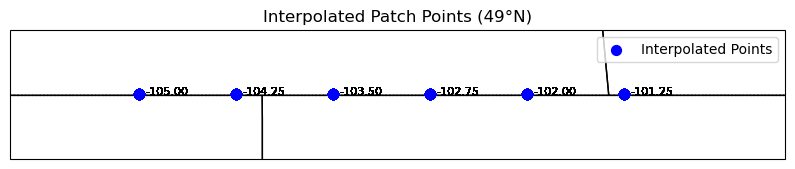

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# --- LOAD PATCH FILE ---
file_path = "/nfs/spare11/dharkin/NWS_Lapenta_Project/patched_parquet_data/2015/ensemble_median_allvars_20150101_20150102.parquet"  # Update if needed
df = pd.read_parquet(file_path)

# --- SET UP MAP ---
fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add features
ax.add_feature(cfeature.STATES, linewidth=1)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.coastlines()

# Scatter plot of the points
ax.scatter(df["longitude"], df["latitude"], color="blue", s=50, label="Interpolated Points", zorder=5)

# Optional: Annotate with lon/lat
for lon, lat in zip(df["longitude"], df["latitude"]):
    ax.text(lon + 0.05, lat, f"{lon:.2f}", fontsize=8, transform=ccrs.PlateCarree())

# Set zoom area (Northern Plains / ND)
ax.set_extent([-106, -100, 48.5, 49.5], crs=ccrs.PlateCarree())

plt.title("Interpolated Patch Points (49°N)")
plt.legend()
plt.grid(True)
plt.show()


## Fastest Patching Code

In [1]:
import os
import pandas as pd
import numpy as np
from scipy.interpolate import griddata
from concurrent.futures import ProcessPoolExecutor

# === CONFIG ===

target_points = np.array([
    (49.0, -105.0),
    (49.0, -104.25),
    (49.0, -103.5),
    (49.0, -102.75),
    (49.0, -102.0),
    (49.0, -101.25),
])

INPUT_DIR = "/nfs/spare11/dharkin/NWS_Lapenta_Project/correct_parquet_data/2015"
PATCH_DIR = "/nfs/spare11/dharkin/NWS_Lapenta_Project/patched_parquet_data/2015"

EXCLUDE_COLS = {"latitude", "longitude", "forecast_lead_hours", "init_time", "valid_time"}

os.makedirs(PATCH_DIR, exist_ok=True)

def needs_patch(df):
    """Return True if any NW ND longitudes at 49N are missing."""
    df_49 = df[df["latitude"] == 49.0]
    present_lons = set(np.round(df_49["longitude"].unique(), 4))
    required_lons = set(p[1] for p in target_points)
    return not required_lons.issubset(present_lons)

def interpolate_patch(parquet_path):
    try:
        df = pd.read_parquet(parquet_path)
        if not needs_patch(df):
            return f"✅ Skipped: {os.path.basename(parquet_path)}"

        vars_to_interp = [col for col in df.columns if col not in EXCLUDE_COLS]

        results = []
        for (lead, init), group in df.groupby(["forecast_lead_hours", "init_time"]):
            grid_points = np.column_stack((group["latitude"].values, group["longitude"].values))
            result = {
                "forecast_lead_hours": np.full(len(target_points), lead),
                "init_time": np.full(len(target_points), init),
                "latitude": target_points[:, 0],
                "longitude": target_points[:, 1],
            }

            for var in vars_to_interp:
                values = group[var].values
                interp_vals = griddata(grid_points, values, target_points, method="linear")

                if np.isnan(interp_vals).any():
                    fallback = griddata(grid_points, values, target_points, method="nearest")
                    interp_vals = np.where(np.isnan(interp_vals), fallback, interp_vals)

                result[var] = interp_vals

            patch_df = pd.DataFrame(result)

            # Add valid_time column like original files
            patch_df["valid_time"] = patch_df["init_time"] + pd.to_timedelta(patch_df["forecast_lead_hours"], unit="h")

            # Reorder columns to match original
            patch_df = patch_df[df.columns.tolist()]

            # Align dtypes to original
            for col in patch_df.columns:
                if col in df.columns:
                    patch_df[col] = patch_df[col].astype(df[col].dtype)

            results.append(patch_df)

        patch_df = pd.concat(results, ignore_index=True)

        out_path = os.path.join(PATCH_DIR, os.path.basename(parquet_path))
        patch_df.to_parquet(out_path, index=False, engine='pyarrow', compression='snappy')

        # Optional: quick check print
        print(f"Patched {os.path.basename(parquet_path)}: {patch_df.shape[0]} rows")

        return f"✅ Patched: {os.path.basename(parquet_path)}"

    except Exception as e:
        return f"❌ Error: {os.path.basename(parquet_path)} | {e}"

def main():
    all_parquets = [
        os.path.join(INPUT_DIR, f)
        for f in os.listdir(INPUT_DIR)
        if f.endswith(".parquet")
    ]

    print(f"🔍 Scanning {len(all_parquets)} Parquet files in {INPUT_DIR}...\n")

    with ProcessPoolExecutor() as executor:
        results = list(executor.map(interpolate_patch, all_parquets))

    print("\n=== Summary ===")
    for res in results:
        print(res)

if __name__ == "__main__":
    main()


🔍 Scanning 137 Parquet files in /nfs/spare11/dharkin/NWS_Lapenta_Project/correct_parquet_data/2015...

Patched ensemble_median_allvars_20150302_20150303.parquet: 732 rows
Patched ensemble_median_allvars_20150125_20150126.parquet: 732 rowsPatched ensemble_median_allvars_20151104_20151105.parquet: 732 rows

Patched ensemble_median_allvars_20151023_20151024.parquet: 732 rows
Patched ensemble_median_allvars_20150103_20150104.parquet: 732 rows
Patched ensemble_median_allvars_20150907_20150908.parquet: 732 rows
Patched ensemble_median_allvars_20151210_20151211.parquet: 732 rowsPatched ensemble_median_allvars_20151202_20151203.parquet: 732 rows

Patched ensemble_median_allvars_20151021_20151022.parquet: 732 rows
Patched ensemble_median_allvars_20150919_20150920.parquet: 732 rowsPatched ensemble_median_allvars_20151108_20151109.parquet: 732 rows

Patched ensemble_median_allvars_20151011_20151012.parquet: 732 rows
Patched ensemble_median_allvars_20150312_20150313.parquet: 732 rows
Patched ensem

In [54]:
if __name__ == "__main__":
    # Provide the filename you want to patch
    one_file = "ensemble_median_allvars_20190531.parquet"  # <== change as needed

    parquet_path = os.path.join(INPUT_DIR, one_file)
    
    print(f"🔧 Patching single file: {parquet_path}")
    result = interpolate_patch(parquet_path)
    print(result)


🔧 Patching single file: /nfs/spare11/dharkin/NWS_Lapenta_Project/correct_parquet_data/2019/ensemble_median_allvars_20190531.parquet
❌ Error: ensemble_median_allvars_20190531.parquet | [Errno 2] No such file or directory: '/nfs/spare11/dharkin/NWS_Lapenta_Project/correct_parquet_data/2019/ensemble_median_allvars_20190531.parquet'


In [16]:
import pandas as pd

# Load the Parquet file
df = pd.read_parquet("/nfs/spare11/dharkin/NWS_Lapenta_Project/correct_parquet_data/2019/ensemble_median_allvars_20190111_20190112.parquet")

# Get unique longitude values
unique_lons = df["longitude"].unique()
unique_lats = df["latitude"].unique()
# Sort and print
unique_lons = sorted(unique_lons)
unique_lats = sorted(unique_lats)
print(unique_lats)
print(unique_lons)


[np.float64(40.0), np.float64(40.75), np.float64(41.5), np.float64(42.25), np.float64(43.0), np.float64(43.75), np.float64(44.5), np.float64(45.25), np.float64(46.0), np.float64(46.75), np.float64(47.5), np.float64(48.25), np.float64(49.0)]
[np.float64(-105.0), np.float64(-104.25), np.float64(-103.5), np.float64(-102.75), np.float64(-102.0), np.float64(-101.25), np.float64(-100.5), np.float64(-99.75), np.float64(-99.0), np.float64(-98.25), np.float64(-97.5), np.float64(-96.75), np.float64(-96.0), np.float64(-95.25), np.float64(-94.5), np.float64(-93.75), np.float64(-93.0), np.float64(-92.25), np.float64(-91.5), np.float64(-90.75), np.float64(-90.0)]


In [9]:
import pandas as pd

def query_parquet_by_date(parquet_path, query_date):
    """
    Load Parquet and filter rows by init_time date.

    Parameters:
    - parquet_path: str or Path to Parquet file
    - query_date: str in 'YYYY-MM-DD' format or datetime.date object

    Returns:
    - Filtered DataFrame with rows matching the init_time date
    """
    # Load the entire Parquet file
    df = pd.read_parquet(parquet_path)

    # Convert query_date to string if it's datetime.date or datetime.datetime
    if not isinstance(query_date, str):
        query_date = query_date.strftime("%Y-%m-%d")

    # Ensure init_time is datetime type (in case it's not)
    if not pd.api.types.is_datetime64_any_dtype(df['init_time']):
        df['init_time'] = pd.to_datetime(df['init_time'])

    # Filter rows where init_time date matches query_date
    filtered = df[df['init_time'].dt.strftime("%Y-%m-%d") == query_date]

    print(f"Number of rows for init_time = {query_date}: {len(filtered)}")
    if len(filtered) > 0:
        display(filtered.head())
    else:
        print("No rows found for this date.")

    return filtered

# --- Example usage ---
parquet_file = "/nfs/spare11/dharkin/NWS_Lapenta_Project/yearly_data_files/years_2015_2019_fixedtrimmed.parquet"  # <-- change this to your file
date_to_query = "2019-10-10"  # <-- change this to your desired date

filtered_df = query_parquet_by_date(parquet_file, date_to_query)


Number of rows for init_time = 2019-10-10: 15738


,latitude,longitude,valid_time,forecast_lead_hours,init_time,t2m,msl,sh2,apcp,pwat,...,snowfall_ge_4in,snowfall_ge_6in,tsoil_missing,sdwe_missing,sfcr_missing,pbl_hgt_missing,lapse_500_700,lapse_700_850,wetbulb_sfc,wetbulb_850
20065950,40.0,-105.0,2019-10-12 12:00:00,60.0,2019-10-10,271.805756,101902.937500,0.001780,0.0,3.4,...,0,0,0.0,0.0,0.0,0.0,7.086960,0.839037,-4.538366,-2.475054
20065951,40.0,-105.0,2019-10-12 15:00:00,63.0,2019-10-10,278.118042,101655.671875,0.002340,0.0,3.6,...,0,0,0.0,0.0,0.0,0.0,7.239728,2.865081,0.353501,0.046387
20065952,40.0,-105.0,2019-10-12 18:00:00,66.0,2019-10-10,286.261963,101199.328125,0.002250,0.0,3.8,...,0,0,0.0,0.0,0.0,0.0,7.313848,7.277873,4.937700,4.344051
20065953,40.0,-105.0,2019-10-12 21:00:00,69.0,2019-10-10,290.158234,100808.101562,0.002133,0.0,4.3,...,0,0,0.0,0.0,0.0,0.0,7.472014,8.946343,6.695983,6.185001
20065954,40.0,-105.0,2019-10-13 00:00:00,72.0,2019-10-10,284.592743,100858.937500,0.002680,0.0,4.6,...,0,0,0.0,0.0,0.0,0.0,7.305253,7.330044,4.570378,5.725188


### Merged File Code

In [34]:
import pandas as pd
import os

# Your file paths
original_path = "/nfs/spare11/dharkin/NWS_Lapenta_Project/correct_parquet_data/2015/ensemble_median_allvars_20150101_20150102.parquet"
patch_path = "/nfs/spare11/dharkin/NWS_Lapenta_Project/patched_parquet_data/2015/ensemble_median_allvars_20150101_20150102.parquet"
output_path = "/nfs/spare11/dharkin/NWS_Lapenta_Project/final_parquet_data/2015/ensemble_median_allvars_final_20150101_20150102.parquet"

# Load data
df_original = pd.read_parquet(original_path)
df_patch = pd.read_parquet(patch_path)

# Combine
df_merged = pd.concat([df_original, df_patch], ignore_index=True)

# Ensure output directory exists
output_dir = os.path.dirname(output_path)
os.makedirs(output_dir, exist_ok=True)

# Save merged Parquet
df_merged.to_parquet(output_path, index=False)
print(f"Saved merged file to {output_path}")


Saved merged file to /nfs/spare11/dharkin/NWS_Lapenta_Project/final_parquet_data/2015/ensemble_median_allvars_final_20150101_20150102.parquet


In [25]:
import pandas as pd

parquet_path = "/nfs/spare11/dharkin/NWS_Lapenta_Project/final_parquet_data/2015/ensemble_median_allvars_final_20150101_20150102.parquet"  # update with your file path

df = pd.read_parquet(parquet_path)

print(df.head())  # preview first few rows


   latitude  longitude          valid_time  forecast_lead_hours  init_time  \
0      40.0     -105.0 2015-01-03 12:00:00                   60 2015-01-01   
1      40.0     -105.0 2015-01-03 15:00:00                   63 2015-01-01   
2      40.0     -105.0 2015-01-03 18:00:00                   66 2015-01-01   
3      40.0     -105.0 2015-01-03 21:00:00                   69 2015-01-01   
4      40.0     -105.0 2015-01-04 00:00:00                   72 2015-01-01   

          t2m            msl      sh2  apcp      pwat  ...     q_500  \
0  267.210510  101069.773438  0.00192   0.0  5.000000  ...  0.000710   
1  268.855560  101384.132812  0.00262   0.0  7.400000  ...  0.000895   
2  270.668365  101512.375000  0.00327   1.6  7.800000  ...  0.000789   
3  265.913757  101980.609375  0.00251   1.2  6.216374  ...  0.000379   
4  262.187256  102694.992188  0.00181   2.4  4.800000  ...  0.000465   

      w_500  snowfall_nohrsc_m  snowfall_ge_1in  snowfall_ge_4in  \
0 -0.056291           0.000000

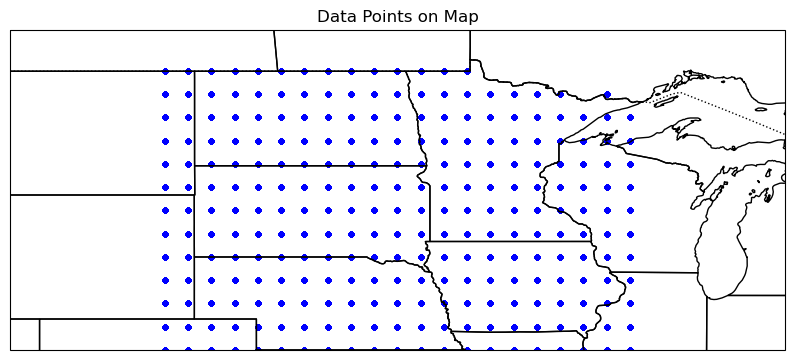

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Load your parquet file
parquet_path = "/nfs/spare11/dharkin/NWS_Lapenta_Project/final_parquet_data/2015/ensemble_median_allvars_final_20150101_20150102.parquet"  # Update this
df = pd.read_parquet(parquet_path)

# Create map plot
plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.STATES, linewidth=1)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.coastlines()

# Scatter plot of points
ax.scatter(df['longitude'], df['latitude'], s=10, color='blue', alpha=0.7, transform=ccrs.PlateCarree())

# Set extent to zoom to your area of interest (adjust as needed)
ax.set_extent([-110, -85, 40, 50])  # example for Northern Plains

plt.title("Data Points on Map")
plt.show()


### Patched Files Concat

In [25]:
import pandas as pd
from pathlib import Path
from tqdm import tqdm

# ── Configure ───────────────────────────
input_dir  = Path(r"/nfs/spare11/dharkin/NWS_Lapenta_Project/patched_parquet_data/2015")  # patched source folder
output_dir = Path(r"/nfs/spare11/dharkin/NWS_Lapenta_Project/yearly_data_files")          # output folder
output_dir.mkdir(parents=True, exist_ok=True)
output_f   = output_dir / "year_2015_patched.parquet"  # distinguish patched file

# ── Load and Concatenate ────────────────
files = sorted(input_dir.glob("*.parquet"))

print(f"📁 Found {len(files)} patched files. Loading...")

dfs = []
for f in tqdm(files, desc="Reading patched files"):
    df = pd.read_parquet(f)

    # Downcast float64 columns to float32 to reduce file size
    float64_cols = df.select_dtypes(include="float64").columns
    df[float64_cols] = df[float64_cols].astype("float32")

    dfs.append(df)

df_full = pd.concat(dfs, ignore_index=True)

print(f"✅ Combined patched shape: {df_full.shape}")

# ── Save as one Parquet ─────────────────
df_full.to_parquet(output_f, engine="pyarrow", compression="snappy", index=False)

print(f"🎉 Saved full patched year to: {output_f}")


📁 Found 137 patched files. Loading...


Reading patched files: 100%|██████████| 137/137 [00:08<00:00, 16.07it/s]


✅ Combined patched shape: (99918, 43)
🎉 Saved full patched year to: /nfs/spare11/dharkin/NWS_Lapenta_Project/yearly_data_files/year_2015_patched.parquet


In [4]:
import pandas as pd
from pathlib import Path
from tqdm import tqdm

# ── Configure ───────────────────────────
input_dir  = Path("/nfs/spare11/dharkin/NWS_Lapenta_Project/yearly_data_files/patched_yearly_files")
output_f   = input_dir / "2015_2019_patched.parquet"

# Only include yearly files (patched or not)
files = sorted(input_dir.glob("year_*.parquet"))

print(f"📁 Found {len(files)} yearly files. Combining...")

dfs = []
for f in tqdm(files, desc="Reading yearly Parquet files"):
    df = pd.read_parquet(f)

    # Optional: downcast float64 to float32
    float64_cols = df.select_dtypes(include="float64").columns
    df[float64_cols] = df[float64_cols].astype("float32")

    dfs.append(df)

# ── Combine all years ───────────────────
df_full = pd.concat(dfs, ignore_index=True)
print(f"✅ Combined 5-year shape: {df_full.shape}")

# ── Save final Parquet ──────────────────
df_full.to_parquet(output_f, engine="pyarrow", compression="snappy", index=False)
print(f"🎉 Final 5-year file saved to: {output_f}")


📁 Found 5 yearly files. Combining...


Reading yearly Parquet files: 100%|██████████| 5/5 [00:00<00:00,  7.29it/s]


✅ Combined 5-year shape: (500322, 43)
🎉 Final 5-year file saved to: /nfs/spare11/dharkin/NWS_Lapenta_Project/yearly_data_files/patched_yearly_files/2015_2019_patched.parquet


### full, complete file merge process

#### Checking for Nans

In [10]:
import pandas as pd
from pathlib import Path

# ── Path to final combined file ────────
file_path = Path("/nfs/spare11/dharkin/NWS_Lapenta_Project/yearly_data_files/years_2015_2019_trimmed.parquet")

# ── Load Data ──────────────────────────
print("📥 Loading final merged 5-year file...")
df = pd.read_parquet(file_path)
print(f"🔹 Data shape: {df.shape}")

# ── NaN Summary ────────────────────────
print("\n🔍 Checking for NaNs in each column...\n")
nan_summary = df.isna().sum()
nan_summary = nan_summary[nan_summary > 0]  # only show columns with NaNs

if nan_summary.empty:
    print("✅ No missing values in any column!")
else:
    print("⚠️ Columns with missing values:\n")
    print(nan_summary.sort_values(ascending=False))


📥 Loading final merged 5-year file...
🔹 Data shape: (21372204, 47)

🔍 Checking for NaNs in each column...

⚠️ Columns with missing values:

lapse_700_850    974776
lapse_500_700       529
dtype: int64


In [12]:
import pandas as pd
from pathlib import Path

# ── Path to final combined file ────────
file_path = Path("/nfs/spare11/dharkin/NWS_Lapenta_Project/yearly_data_files/patched_yearly_files/2015_2019_patched_phased.parquet")

# ── Load Data ──────────────────────────
print("📥 Loading final merged 5-year file...")
df = pd.read_parquet(file_path)
print(f"🔹 Data shape: {df.shape}")

# ── NaN Summary ────────────────────────
print("\n🔍 Checking for NaNs in each column...\n")
nan_summary = df.isna().sum()
nan_summary = nan_summary[nan_summary > 0]  # only show columns with NaNs

if nan_summary.empty:
    print("✅ No missing values in any column!")
else:
    print("⚠️ Columns with missing values:\n")
    print(nan_summary.sort_values(ascending=False))


📥 Loading final merged 5-year file...
🔹 Data shape: (497028, 46)

🔍 Checking for NaNs in each column...

✅ No missing values in any column!


#### Determine the common columns

In [15]:
import pandas as pd
from pathlib import Path

# Paths to the two Parquet files
file1 = Path("/nfs/spare11/dharkin/NWS_Lapenta_Project/yearly_data_files/years_2015_2019_trimmed.parquet")
file2 = Path("/nfs/spare11/dharkin/NWS_Lapenta_Project/yearly_data_files/patched_yearly_files/2015_2019_patched_phased.parquet")

# Load metadata (schema only) using PyArrow backend
import pyarrow.parquet as pq

cols1 = pq.read_schema(file1).names
cols2 = pq.read_schema(file2).names

print(f"\n📁 File 1 ({file1.name}) has {len(cols1)} columns:")
print(cols1)

print(f"\n📁 File 2 ({file2.name}) has {len(cols2)} columns:")
print(cols2)

# Show the difference
print("\n🔍 Columns in File 2 but not in File 1:")
print([col for col in cols2 if col not in cols1])

print("\n🔍 Columns in File 1 but not in File 2:")
print([col for col in cols1 if col not in cols2])



📁 File 1 (years_2015_2019_trimmed.parquet) has 47 columns:
['latitude', 'longitude', 'valid_time', 'forecast_lead_hours', 'init_time', 't2m', 'msl', 'sh2', 'apcp', 'pwat', 'ugrd_10m', 'vgrd_10m', 'sfcr', 'gust', 'pbl_hgt', 'sdwe', 'tsoil', 'u_700', 'v_700', 't_700', 'gh_700', 'q_700', 'w_700', 'u_850', 'v_850', 't_850', 'gh_850', 'q_850', 'w_850', 'u_500', 'v_500', 't_500', 'gh_500', 'q_500', 'w_500', 'snowfall_nohrsc_m', 'snowfall_ge_1in', 'snowfall_ge_4in', 'snowfall_ge_6in', 'tsoil_missing', 'sdwe_missing', 'sfcr_missing', 'pbl_hgt_missing', 'lapse_500_700', 'lapse_700_850', 'wetbulb_sfc', 'wetbulb_850']

📁 File 2 (2015_2019_patched_phased.parquet) has 46 columns:
['latitude', 'longitude', 'valid_time', 'forecast_lead_hours', 'init_time', 't2m', 'msl', 'sh2', 'apcp', 'pwat', 'ugrd_10m', 'vgrd_10m', 'sfcr', 'gust', 'pbl_hgt', 'sdwe', 'tsoil', 'u_700', 'v_700', 't_700', 'gh_700', 'q_700', 'w_700', 'u_850', 'v_850', 't_850', 'gh_850', 'q_850', 'w_850', 'u_500', 'v_500', 't_500', 'gh_5

### Phase metrics

In [18]:
import numpy as np
import pandas as pd

# --- Constants ---
EPS = 0.622  # Rd / Rv

def rh_from_q(T_K, p_Pa, q):
    T_C = T_K - 273.15
    es = 6.112 * np.exp((17.67 * T_C) / (T_C + 243.5))        # hPa
    e = (q * p_Pa) / (EPS + (1 - EPS) * q) / 100.0           # Pa → hPa
    RH = 100.0 * e / es
    return np.clip(RH, 0.0, 100.0).astype(np.float32)

def wetbulb_stull(T_C, RH):
    Tw = (T_C * np.arctan(0.151977 * np.sqrt(RH + 8.313659))
          + np.arctan(T_C + RH)
          - np.arctan(RH - 1.676331)
          + 0.00391838 * RH**1.5 * np.arctan(0.023101 * RH)
          - 4.686035)
    return Tw.astype(np.float32)

def calculate_phase_metrics(df):
    # Surface wet-bulb
    RH_sfc = rh_from_q(df["t2m"].values, df["msl"].values, df["sh2"].values)
    df["wetbulb_sfc"] = wetbulb_stull(df["t2m"].values - 273.15, RH_sfc)

    # 850 mb wet-bulb
    p850 = 85000.0  # Pa
    RH_850 = rh_from_q(df["t_850"].values, p850, df["q_850"].values)
    df["wetbulb_850"] = wetbulb_stull(df["t_850"].values - 273.15, RH_850)

    # Freezing-level height interpolation
    T_sfc = df["t2m"].values - 273.15
    T_850 = df["t_850"].values - 273.15
    T_700 = df["t_700"].values - 273.15
    z_850 = df["gh_850"].values
    z_700 = df["gh_700"].values

    fl = np.full_like(T_sfc, np.nan, dtype=np.float32)

    # Case 1: freezing level between surface and 850 mb
    mask1 = np.sign(T_sfc) * np.sign(T_850) <= 0
    frac1 = np.divide(0 - T_sfc, T_850 - T_sfc, where=mask1 & (T_850 != T_sfc))
    fl[mask1] = (frac1[mask1] * z_850[mask1]).astype(np.float32)

    # Case 2: freezing level between 850 and 700 mb
    mask2 = ~mask1 & (np.sign(T_850) * np.sign(T_700) <= 0)
    frac2 = np.divide(0 - T_850, T_700 - T_850, where=mask2 & (T_700 != T_850))
    fl[mask2] = (z_850[mask2] + frac2[mask2] * (z_700[mask2] - z_850[mask2])).astype(np.float32)

    df["freezing_level_m"] = fl
    df["freezing_level_m"] = df["freezing_level_m"].fillna(0.0)

    return df
    
# ————————————————————————————————————

input_parquet = "/nfs/spare11/dharkin/NWS_Lapenta_Project/yearly_data_files/years_2015_2019.parquet"
output_parquet = "/nfs/spare11/dharkin/NWS_Lapenta_Project/yearly_data_files/years_2015_2019_phased.parquet"

print("Loading Parquet data...")
df = pd.read_parquet(input_parquet)

print("Calculating phase metrics...")
df = calculate_phase_metrics(df)

print("Saving augmented data to Parquet...")
df.to_parquet(output_parquet, engine="pyarrow", compression="zstd")

print(f"Done! Saved to {output_parquet}")


Loading Parquet data...
Calculating phase metrics...
Saving augmented data to Parquet...
Done! Saved to /nfs/spare11/dharkin/NWS_Lapenta_Project/yearly_data_files/years_2015_2019_phased.parquet


### Final Merging Code (Patched and Normal)

In [19]:
import pandas as pd
from pathlib import Path

# ── Paths ───────────────────────────────
original_file = "/nfs/spare11/dharkin/NWS_Lapenta_Project/yearly_data_files/years_2015_2019_phased.parquet"
patched_file  = "/nfs/spare11/dharkin/NWS_Lapenta_Project/yearly_data_files/patched_yearly_files/2015_2019_patched_phased.parquet"
output_file   = "/nfs/spare11/dharkin/NWS_Lapenta_Project/yearly_data_files/NorthernPlains_FULL_2015_2019.parquet"

# ── Load data ───────────────────────────
print("📥 Loading original 5-year file...")
df_orig = pd.read_parquet(original_file)
print(f"🔹 Original shape: {df_orig.shape}")

print("📥 Loading patched 5-year file (NW ND points)...")
df_patch = pd.read_parquet(patched_file)
print(f"🔹 Patched shape: {df_patch.shape}")

# ── Drop columns that are not shared ────
shared_cols = sorted(set(df_orig.columns).intersection(df_patch.columns))
df_orig = df_orig[shared_cols]
df_patch = df_patch[shared_cols]
print(f"📐 Columns after alignment: {len(shared_cols)}")

# ── Drop duplicates if any ──────────────
print("🧹 Removing any overlapping rows...")
key_cols = ["latitude", "longitude", "init_time", "forecast_lead_hours"]

df_orig_filtered = df_orig.merge(
    df_patch[key_cols], on=key_cols, how="left", indicator=True
).query("_merge == 'left_only'").drop(columns="_merge")

print(f"✅ Filtered original shape (after dropping duplicates): {df_orig_filtered.shape}")

# ── Combine ─────────────────────────────
df_combined = pd.concat([df_orig_filtered, df_patch], ignore_index=True)
print(f"🎯 Final combined shape: {df_combined.shape}")

# ── Save final combined Parquet ─────────
df_combined.to_parquet(output_file, engine="pyarrow", compression="snappy", index=False)
print(f"💾 Final full 5-year file saved to: {output_file}")


📥 Loading original 5-year file...
🔹 Original shape: (21513846, 46)
📥 Loading patched 5-year file (NW ND points)...
🔹 Patched shape: (500322, 46)
📐 Columns after alignment: 46
🧹 Removing any overlapping rows...
✅ Filtered original shape (after dropping duplicates): (21513846, 46)
🎯 Final combined shape: (22014168, 46)
💾 Final full 5-year file saved to: /nfs/spare11/dharkin/NWS_Lapenta_Project/yearly_data_files/NorthernPlains_FULL_2015_2019.parquet


#### Missing Data Check

In [20]:
import pandas as pd
from pathlib import Path

# ── File to check ───────────────────────
full_file = Path("/nfs/spare11/dharkin/NWS_Lapenta_Project/yearly_data_files/NorthernPlains_FULL_2015_2019.parquet")

# ── Load data ───────────────────────────
print("📥 Loading full 5-year neighborhood file...")
df = pd.read_parquet(full_file)
df["init_time"] = pd.to_datetime(df["init_time"])
df["init_date"] = df["init_time"].dt.floor("D")  # strip time, keep just date

# ── Determine expected daily range ──────
start_date = df["init_date"].min()
end_date   = df["init_date"].max()
all_dates  = pd.date_range(start=start_date, end=end_date, freq="D").date
available_dates = sorted(df["init_date"].dt.date.unique())
missing_dates = sorted(set(all_dates) - set(available_dates))

# ── Filter missing dates to May or September only ───────
missing_filtered = [d for d in missing_dates if d.month in [1, 12]]

# ── Output result ───────────────────────
print(f"📅 Expected init_time range: {start_date.date()} → {end_date.date()}")
print(f"✅ Available init dates: {len(available_dates)}")
print(f"❌ Missing init dates in May or September: {len(missing_filtered)}")

if missing_filtered:
    print("\n🔍 Missing Init Dates (May/September only):")
    for d in missing_filtered:
        print(f"  • {d}")
else:
    print("🎉 No missing init_time days in May or September!")


📥 Loading full 5-year neighborhood file...
📅 Expected init_time range: 2015-01-01 → 2019-12-31
✅ Available init dates: 1366
❌ Missing init dates in May or September: 0
🎉 No missing init_time days in May or September!


### File Comparison